In [1]:
from helpers import ObserveAttentionHelper

import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from tqdm import tqdm
import pandas as pd;

/home/mohsen/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/mohsen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "meta-llama/Llama-3.2-3B-Instruct"
max_new_tokens = 10000
prompt = """
Write a detailed essay on the history of artificial intelligence, covering key milestones, influential researchers, and major breakthroughs in the field. Discuss the evolution of AI from its inception to the present day, including the development of machine learning, deep learning, and neural networks. Highlight the impact of AI on various industries and society as a whole, as well as ethical considerations and future prospects for AI technology.
"""

Run and store the q, k...

In [3]:
observer = ObserveAttentionHelper(model_name, max_new_tokens=max_new_tokens)
observer.run_model(prompt)

Loading model: meta-llama/Llama-3.2-3B-Instruct


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.29it/s]


Model loaded on cuda
Prompt length: 81 tokens
Generating 10000 tokens...


100%|█████████▉| 10000/10001 [04:23<00:00, 37.89it/s]


Generation complete. Total tokens generated: 10000
Layers captured: 28


"\nWrite a detailed essay on the history of artificial intelligence, covering key milestones, influential researchers, and major breakthroughs in the field. Discuss the evolution of AI from its inception to the present day, including the development of machine learning, deep learning, and neural networks. Highlight the impact of AI on various industries and society as a whole, as well as ethical considerations and future prospects for AI technology.\nThe history of artificial intelligence (AI) spans over six decades, with significant milestones and breakthroughs that have shaped the field into what it is today. From its inception in the 1950s to the present day, AI has evolved from a theoretical concept to a practical reality, transforming various industries and society as a whole.\n\nOne of the earliest milestones in AI history was the Dartmouth Summer Research Project on Artificial Intelligence, held in 1956. This project, led by John McCarthy, Marvin Minsky, Nathaniel Rochester, and

In [4]:
# observer.save(f"{model_name.split('/')[-1]}_attention_data_{max_new_tokens}.pt")
observer = ObserveAttentionHelper.from_file(f"{model_name.split('/')[-1]}_attention_data_{max_new_tokens}.pt")

Data saved to Llama-3.2-3B-Instruct_attention_data_10000.pt


In [5]:
attn_info = observer.get_attention_info()
attn_info

{'num_layers': 28,
 'num_q_heads': 24,
 'num_kv_heads': 8,
 'head_dim': 128,
 'prompt_length': 81,
 'num_generated': 10000,
 'total_tokens': 10081,
 'uses_gqa': True}

## Analysis

### Score distribution

In [6]:
attn_info

{'num_layers': 28,
 'num_q_heads': 24,
 'num_kv_heads': 8,
 'head_dim': 128,
 'prompt_length': 81,
 'num_generated': 10000,
 'total_tokens': 10081,
 'uses_gqa': True}

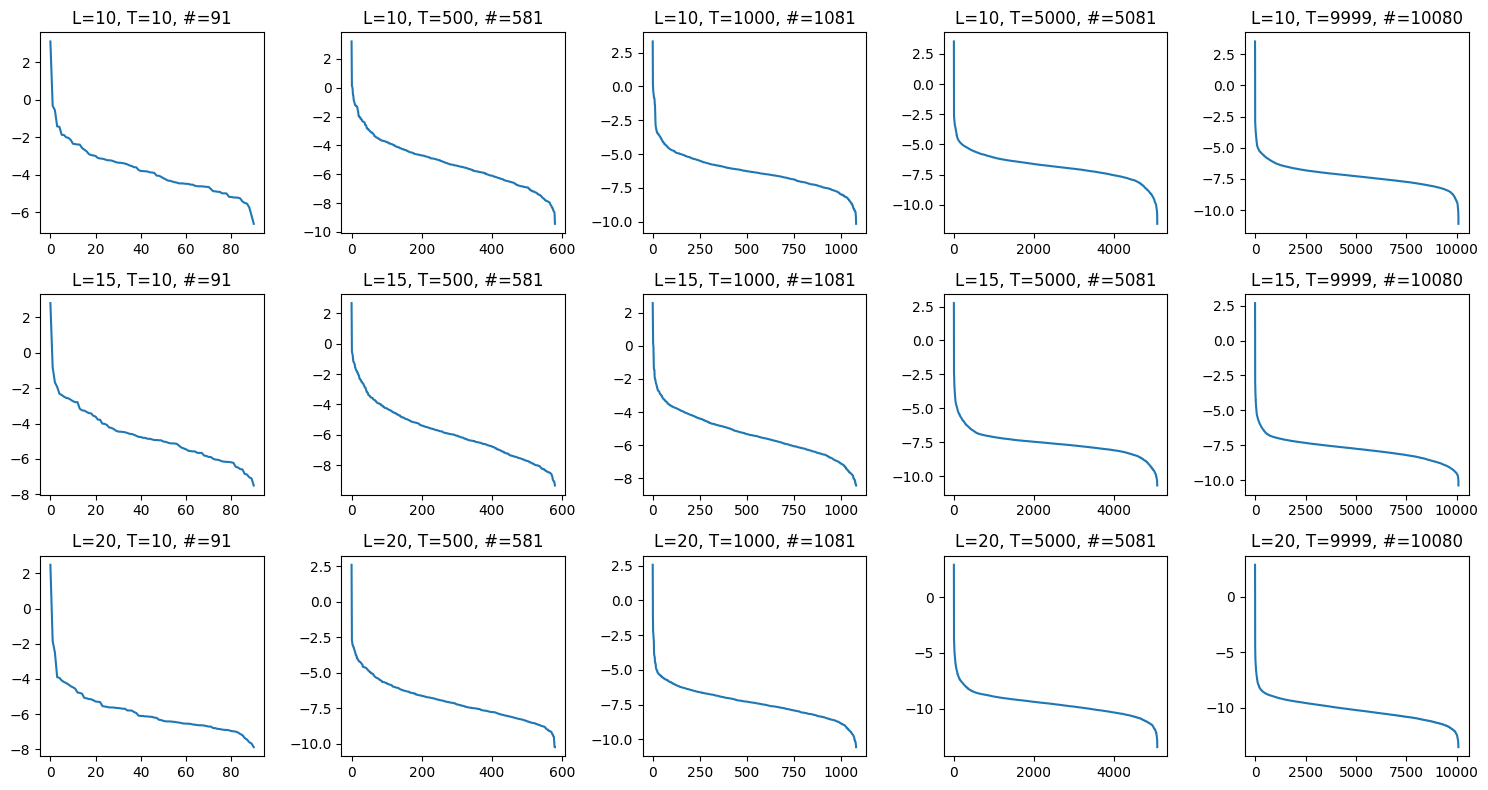

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(15, 8))

for i, layer_idx in enumerate([10, 15, 20]):
    for j, token_idx in enumerate([10, 500, 1000, 5000, 9999]):
        print(f"plotting layer {layer_idx}, token {token_idx}", end="\r")
        stats = observer.get_stats_at_token(token_idx)[layer_idx]
        scores = None
        for head in range(attn_info["num_q_heads"]):
            if scores is None:
                scores = stats[head]["scores"]
            else:
                scores += stats[head]["scores"]

        # Main plotting line:
        scores = scores / attn_info["num_q_heads"]  # Average over heads
        ax = axes[i, j]
        ax.plot(scores.sort().values.tolist()[::-1])
        ax.set_title(f"L={layer_idx}, T={token_idx}, #={len(scores)}")

plt.tight_layout()
plt.show()

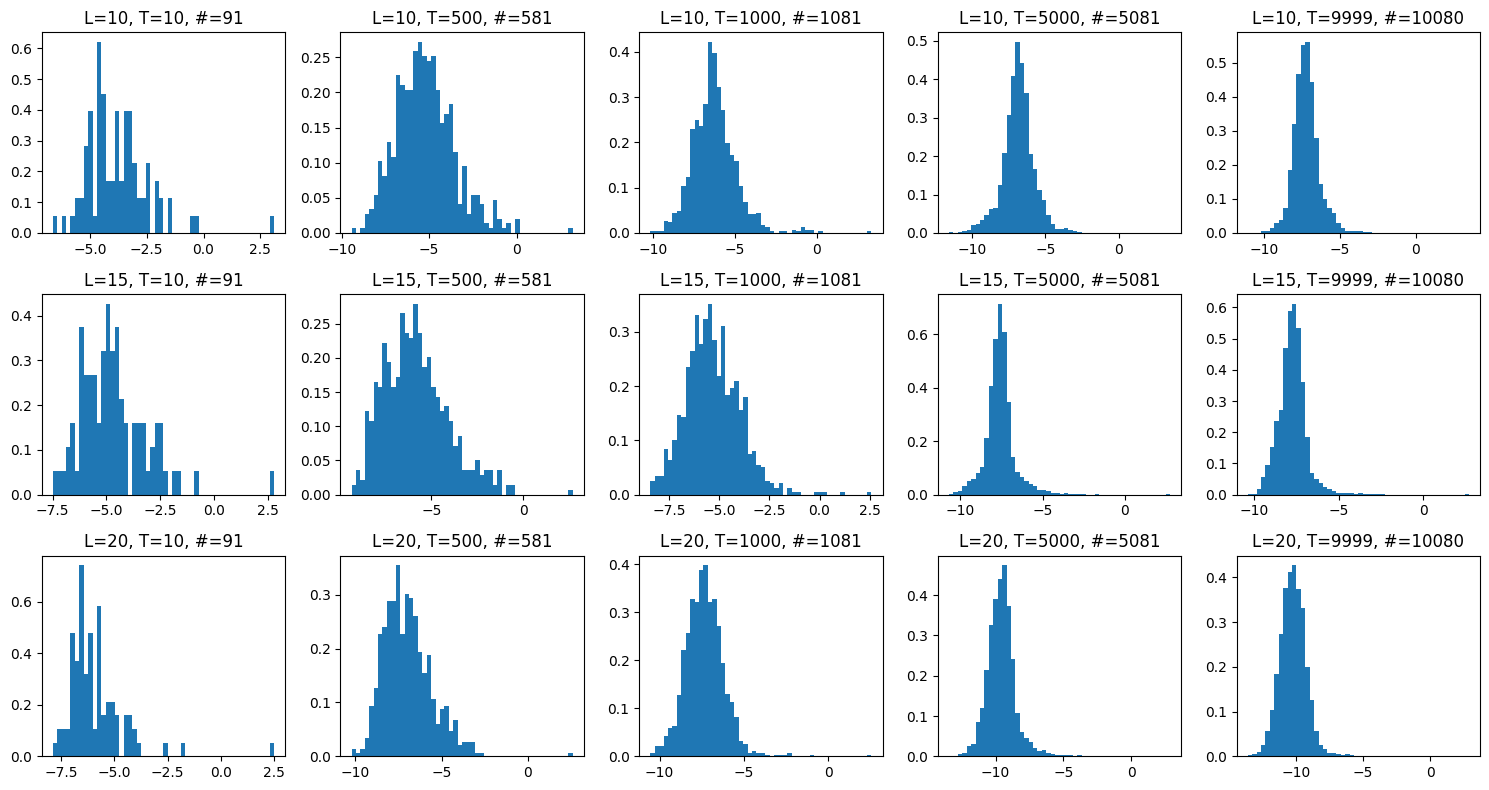

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(15, 8))

for i, layer_idx in enumerate([10, 15, 20]):
    for j, token_idx in enumerate([10, 500, 1000, 5000, 9999]):
        print(f"plotting layer {layer_idx}, token {token_idx}", end="\r")
        stats = observer.get_stats_at_token(token_idx)[layer_idx]
        scores = None
        for head in range(attn_info["num_q_heads"]):
            if scores is None:
                scores = stats[head]["scores"]
            else:
                scores += stats[head]["scores"]

        # Main plotting line:
        scores = scores / attn_info["num_q_heads"]  # Average over heads
        ax = axes[i, j]
        # ax.plot(scores.sort().values.tolist()[::-1])
        ax.hist(scores.tolist(), bins=50, density=True)
        ax.set_title(f"L={layer_idx}, T={token_idx}, #={len(scores)}")

plt.tight_layout()
plt.show()